In [ ]:
# 1) 한글 폰트 설치 (Nanum + Noto CJK KR 백업)
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-noto-cjk > /dev/null

# 2) Matplotlib에 폰트 즉시 등록(재시작 불필요) + 전역 설정
import os, glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 설치된 폰트 경로에서 ttf/otf 파일을 찾아 등록
font_dirs = [
    "/usr/share/fonts/truetype/nanum",
    "/usr/share/fonts/opentype/noto",
    "/usr/share/fonts/noto",
]
font_files = []
for d in font_dirs:
    if os.path.isdir(d):
        font_files += glob.glob(os.path.join(d, "**", "*.ttf"), recursive=True)
        font_files += glob.glob(os.path.join(d, "**", "*.otf"), recursive=True)

for f in font_files:
    try:
        fm.fontManager.addfont(f)
    except Exception:
        pass  # 읽지 못하는 폰트 파일은 건너뜀

# 선호 순서대로 사용할 폰트 이름 선택
preferred = [
    "NanumBarunGothic",  # 있으면 이걸 최우선
    "NanumGothic",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "NanumMyeongjo",
]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((name for name in preferred if name in available), None)

if font_name is None:
    raise RuntimeError("Korean font not found — 설치가 실패했을 수 있어요.")

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False
print("Using font:", font_name)


In [ ]:
import numpy as np
import os

import matplotlib.pyplot as plt

import keras.layers as layers
import keras.optimizers as optimizers
from keras.models import Model, load_model
from keras import layers
from keras import models
from keras.models import load_model
import keras.backend as K


import ipywidgets
from IPython.display import display, clear_output

# **https://bigvalue.ai**

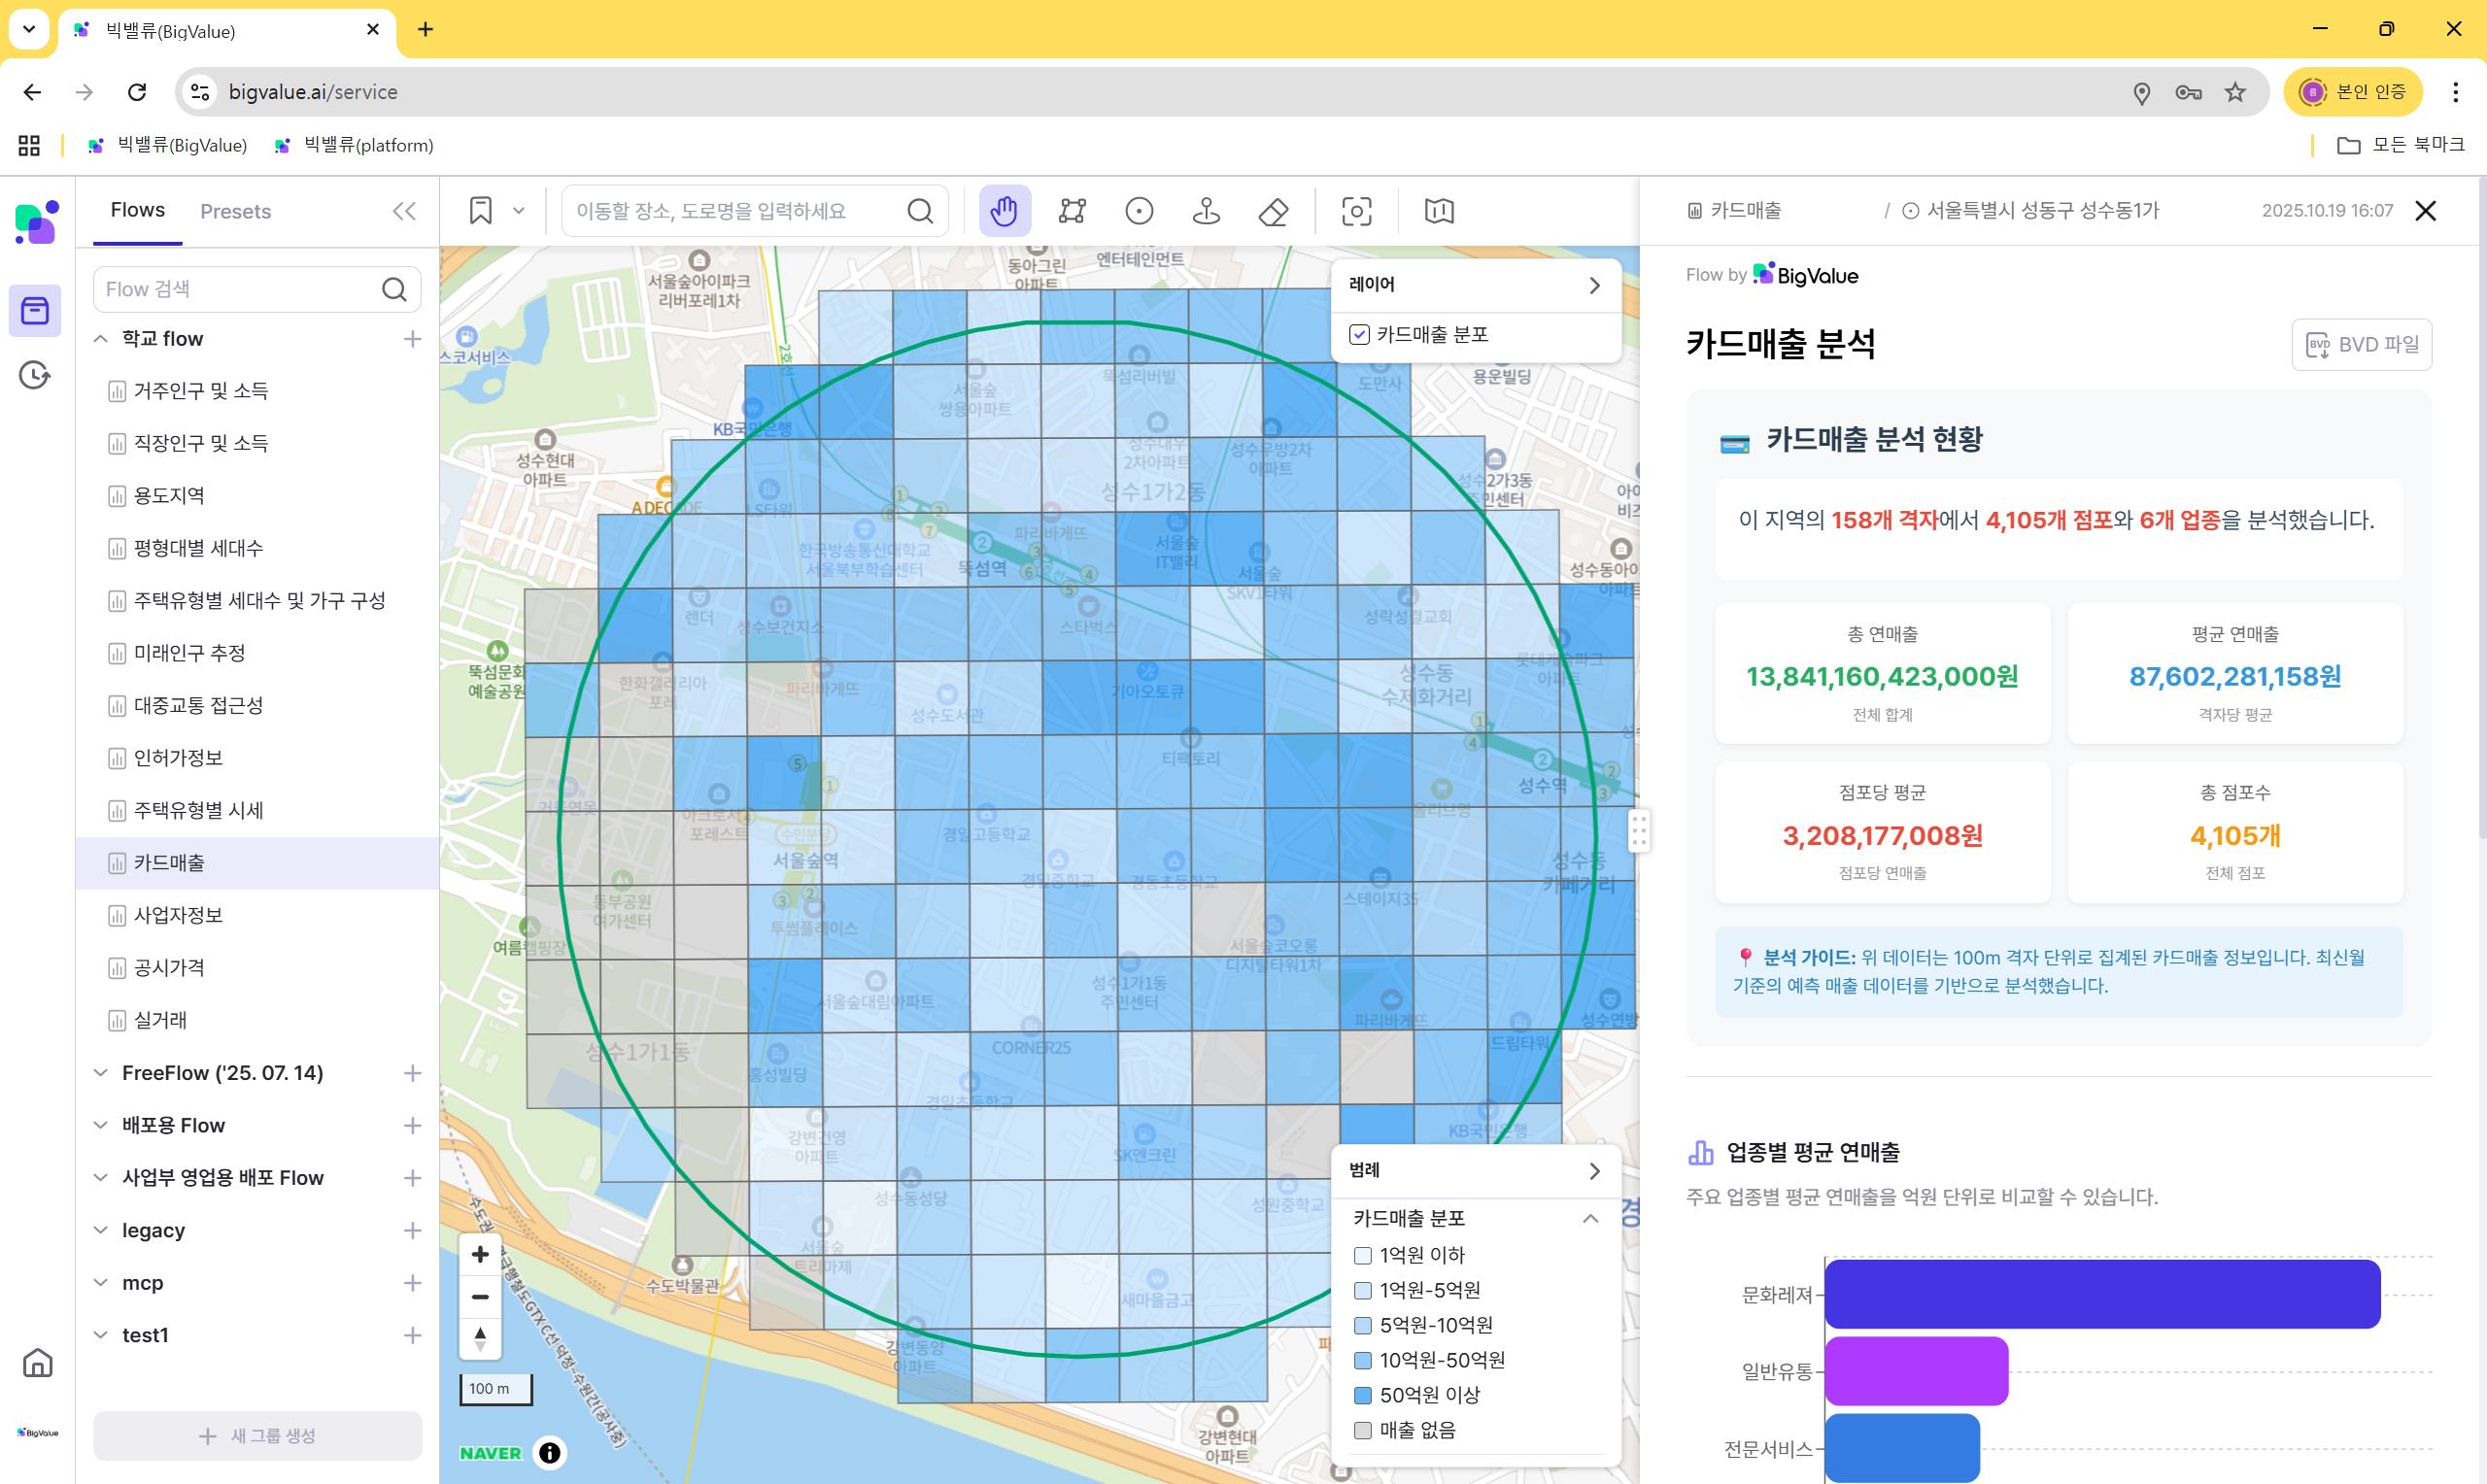

In [ ]:
!wget "https://hycms.hanyang.ac.kr/index.php?module=xn_media_content2013&act=dispXn_media_content2013DownloadContent&content_id=68f4ca277bd76" -O "data.zip"
!unzip  -O cp949 "data.zip" -d "data"

In [ ]:
import pandas as pd
import os
import re
from pathlib import Path
from collections import defaultdict
import numpy as np
from sklearn.cluster import DBSCAN

def parse_filename(filename):
    """
    Extract date, time, file type from filename
    Example: 2025-10-19 1546_업종별 직장인구 및 소득 상세 정보_구름.xlsx
    Returns: (date, time, file_type)
    """
    # Remove duplicate markers
    filename = re.sub(r'\s*\(\d+\)', '', filename)

    pattern = r'^(\d{4}-\d{2}-\d{2})\s+(\d+)_(.+?)_(.+?)\.xlsx$'
    match = re.match(pattern, filename)

    if match:
        date = match.group(1)
        time = match.group(2)
        file_type = match.group(3)
        return date, time, file_type
    return None, None, None

def parse_grid_id(grid_id):
    """Parse grid ID: region + x(3) + y(3)"""
    match = re.match(r'^([가-힣]+)(\d{6})$', str(grid_id))
    if match:
        region = match.group(1)
        coords = match.group(2)
        x = int(coords[:3])
        y = int(coords[3:])
        return region, x, y
    return None, None, None

def load_and_merge_by_time(data_folder='data'):
    """
    Load files and merge by exact date+time match with same grid IDs
    Only keeps times where all 3 file types exist
    """
    data_path = Path(data_folder)

    # Check if data folder exists
    if not data_path.exists():
        print(f"Warning: {data_folder} folder not found!")
        print("Attempting to use existing merged_result.xlsx...")

        if Path('merged_result.xlsx').exists():
            print("Loading from merged_result.xlsx...")
            df = pd.read_excel('merged_result.xlsx')

            # Filter to keep only times with all 3 data types
            required_patterns = {
                '연령대별': '연령대별_거주인구_및_소득_상세_정보_총인구수',
                '업종별': '업종별_직장인구_및_소득_상세_정보_총직장인구수',
                '카드매출': '카드매출_상세_정보_총연매출'
            }

            times = sorted(df['number'].unique())
            valid_times = []

            print("\nChecking data availability by time:")
            for time in times:
                df_time = df[df['number'] == time]
                has_all = True

                for dtype, col_pattern in required_patterns.items():
                    matching_cols = [c for c in df.columns if col_pattern in c]
                    if matching_cols:
                        col = matching_cols[0]
                        non_null = df_time[col].notna().sum()
                        if non_null == 0:
                            has_all = False
                    else:
                        has_all = False

                if has_all:
                    valid_times.append(time)
                    print(f"  Time {time}: OK")
                else:
                    print(f"  Time {time}: NO (missing data)")

            print(f"\nValid times: {len(valid_times)}")
            df_filtered = df[df['number'].isin(valid_times)]

            print(f"Filtered data: {len(df_filtered)} rows")
            return df_filtered
        else:
            print("ERROR: No data source found!")
            return None

    files = [f for f in os.listdir(data_path) if f.endswith('.xlsx') and not f.startswith('~$')]

    # Group files by date+time
    file_groups = defaultdict(lambda: {'업종별': None, '연령대별': None, '카드매출': None})

    for file in files:
        date, time, file_type = parse_filename(file)
        if date and time:
            key = f"{date}_{time}"

            if '업종별' in file_type:
                file_groups[key]['업종별'] = file
            elif '연령대별' in file_type:
                file_groups[key]['연령대별'] = file
            elif '카드매출' in file_type:
                file_groups[key]['카드매출'] = file

    print("="*80)
    print("FILES GROUPED BY DATE+TIME")
    print("="*80)

    # Filter: keep only times with all 3 file types
    complete_times = []
    for key, files_dict in sorted(file_groups.items()):
        has_all = all(files_dict.values())

        date, time = key.split('_')
        if has_all:
            print(f"\n{date} {time}: OK")
            complete_times.append((key, files_dict))
        else:
            print(f"\n{date} {time}: NO (missing files)")

    print(f"\n\nTotal complete time groups: {len(complete_times)}")

    # Merge data for each complete time
    merged_data = []

    for key, files_dict in complete_times:
        date, time = key.split('_')
        print(f"\nProcessing: {date} {time}")

        # Load all 3 files
        dfs = {}
        for ftype, fname in files_dict.items():
            file_path = data_path / fname
            try:
                df = pd.read_excel(file_path)

                # Find grid ID column
                grid_col = None
                for col in df.columns:
                    if 'ID' in col or 'id' in col or '격자' in col:
                        grid_col = col
                        break

                if grid_col:
                    df = df.rename(columns={grid_col: 'grid_id'})
                    dfs[ftype] = df
                    print(f"  {ftype}: {len(df)} rows")

            except Exception as e:
                print(f"  {ftype}: Error - {e}")

        # Check if all 3 loaded successfully
        if len(dfs) == 3:
            # Find common grid IDs (intersection)
            grid_ids_업종별 = set(dfs['업종별']['grid_id'])
            grid_ids_연령대별 = set(dfs['연령대별']['grid_id'])
            grid_ids_카드매출 = set(dfs['카드매출']['grid_id'])

            common_grid_ids = grid_ids_업종별 & grid_ids_연령대별 & grid_ids_카드매출

            print(f"  Common grid IDs: {len(common_grid_ids)}")

            if len(common_grid_ids) > 0:
                # Filter each dataframe to keep only common grid IDs
                df_업종별 = dfs['업종별'][dfs['업종별']['grid_id'].isin(common_grid_ids)].copy()
                df_연령대별 = dfs['연령대별'][dfs['연령대별']['grid_id'].isin(common_grid_ids)].copy()
                df_카드매출 = dfs['카드매출'][dfs['카드매출']['grid_id'].isin(common_grid_ids)].copy()

                # Add prefix to column names (except grid_id)
                for df, prefix in [(df_업종별, '업종별'), (df_연령대별, '연령대별'), (df_카드매출, '카드매출')]:
                    cols_to_rename = {col: f"{prefix}_{col}" for col in df.columns if col != 'grid_id'}
                    df.rename(columns=cols_to_rename, inplace=True)

                # Merge on grid_id (inner join - only common grid IDs)
                merged = df_업종별.merge(df_연령대별, on='grid_id', how='inner')
                merged = merged.merge(df_카드매출, on='grid_id', how='inner')

                # Add time column (convert to int)
                merged['time'] = int(time)

                print(f"  Merged: {len(merged)} rows")

                merged_data.append(merged)

    # Combine all time periods
    if merged_data:
        result_df = pd.concat(merged_data, ignore_index=True)
        print(f"\n{'='*80}")
        print(f"TOTAL MERGED DATA")
        print(f"{'='*80}")
        print(f"Total rows: {len(result_df)}")
        print(f"Unique times: {result_df['time'].nunique()}")

        return result_df
    else:
        print("\nNo data to merge!")
        return None

def convert_to_4d_array(result_df):
    """
    Convert result_df to 4D numpy array with cluster filtering
    """
    # Parse grid IDs
    result_df['region'] = None
    result_df['x'] = None
    result_df['y'] = None

    for idx, row in result_df.iterrows():
        region, x, y = parse_grid_id(row['grid_id'])
        result_df.at[idx, 'region'] = region
        result_df.at[idx, 'x'] = x
        result_df.at[idx, 'y'] = y

    result_df = result_df.dropna(subset=['x', 'y'])
    result_df['x'] = result_df['x'].astype(int)
    result_df['y'] = result_df['y'].astype(int)

    times = sorted(result_df['time'].unique())

    # Filter to largest cluster per time
    print("\n" + "="*80)
    print("FILTERING TO LARGEST CLUSTER PER TIME")
    print("="*80)

    filtered_rows = []
    for time in times:
        df_time = result_df[result_df['time'] == time]

        # Get coordinates
        coords = df_time[['x', 'y']].values

        if len(coords) > 0:
            # Use DBSCAN to find clusters
            clustering = DBSCAN(eps=2, min_samples=1).fit(coords)
            df_time = df_time.copy()
            df_time['cluster'] = clustering.labels_

            # Find largest cluster
            cluster_counts = df_time['cluster'].value_counts()
            largest_cluster = cluster_counts.idxmax()
            df_filtered = df_time[df_time['cluster'] == largest_cluster]

            n_clusters = len(cluster_counts)
            if n_clusters > 1:
                print(f"  Time {time}: {n_clusters} clusters, keeping largest ({len(df_filtered)} rows)")
            else:
                print(f"  Time {time}: Single cluster ({len(df_filtered)} rows)")

            filtered_rows.append(df_filtered)

    result_df = pd.concat(filtered_rows, ignore_index=True)
    print(f"\nTotal rows after filtering: {len(result_df)}")

    # Find max dimensions
    number_ranges = {}
    max_x_count = 0
    max_y_count = 0

    for time in times:
        df_time = result_df[result_df['time'] == time]

        unique_x = sorted(df_time['x'].unique())
        unique_y = sorted(df_time['y'].unique())

        x_count = len(unique_x)
        y_count = len(unique_y)

        x_to_idx = {x: idx for idx, x in enumerate(unique_x)}
        y_to_idx = {y: idx for idx, y in enumerate(unique_y)}

        number_ranges[time] = {
            'unique_x': unique_x,
            'unique_y': unique_y,
            'x_to_idx': x_to_idx,
            'y_to_idx': y_to_idx,
            'x_count': x_count,
            'y_count': y_count
        }

        max_x_count = max(max_x_count, x_count)
        max_y_count = max(max_y_count, y_count)

        print(f"  Time {time}: {x_count} x {y_count}")

    number_count = len(times)

    print(f"\n4D Array dimensions:")
    print(f"  Time count: {number_count}")
    print(f"  Max X count: {max_x_count}")
    print(f"  Max Y count: {max_y_count}")
    print(f"  Features: 3")
    print(f"  Shape: ({number_count}, {max_x_count}, {max_y_count}, 3)")

    # Define feature columns
    feature_cols_base = [
        '연령대별_총인구수',
        '업종별_총직장인구수',
        '연령대별_거주인구추정소득(백만원)'
    ]

    feature_cols = []
    for base_col in feature_cols_base:
        if base_col in result_df.columns:
            feature_cols.append(base_col)
        else:
            # Look for columns with suffixes
            found = False
            for col in result_df.columns:
                if col.startswith(base_col):
                    feature_cols.append(col)
                    found = True
                    break
            if not found:
                print(f"  WARNING: Column not found: {base_col}")
                return None

    print(f"\nUsing columns:")
    for col in feature_cols:
        non_null = result_df[col].notna().sum()
        print(f"  - {col}: {non_null} non-null values")

    # Create 4D array filled with 0
    array_4d = np.zeros((number_count, max_x_count, max_y_count, 3), dtype=np.float32)

    # Fill the array
    for time_idx, time in enumerate(times):
        df_time = result_df[result_df['time'] == time]
        num_range = number_ranges[time]
        x_to_idx = num_range['x_to_idx']
        y_to_idx = num_range['y_to_idx']

        for _, row in df_time.iterrows():
            x = int(row['x'])
            y = int(row['y'])

            if x in x_to_idx and y in y_to_idx:
                x_idx = x_to_idx[x]
                y_idx = y_to_idx[y]

                for feat_idx, col in enumerate(feature_cols):
                    value = row[col]
                    try:
                        array_4d[time_idx, x_idx, y_idx, feat_idx] = float(value) if pd.notna(value) else 0.0
                    except:
                        array_4d[time_idx, x_idx, y_idx, feat_idx] = 0.0

    print(f"\nArray created successfully!")
    print(f"Non-zero values: {np.count_nonzero(array_4d)}")
    print(f"Zero values: {np.sum(array_4d == 0)}")

    metadata = {
        'times': times,
        'number_ranges': number_ranges,
        'max_x_count': max_x_count,
        'max_y_count': max_y_count,
        'feature_names': feature_cols
    }

    return array_4d, metadata, result_df

In [ ]:

# Execute
if __name__ == "__main__":
    print("="*80)
    print("CREATING TRAINING DATA")
    print("="*80)

    result_df = load_and_merge_by_time('data')

    if result_df is not None:
        # Save merged result
        result_df.to_excel('merged_result_final.xlsx', index=False)
        print(f"\nMerged data saved to 'merged_result_final.xlsx'")

        # Convert to 4D array
        result = convert_to_4d_array(result_df)

        if result is not None:
            array_4d, metadata, df_with_coords = result

            # Save 4D array
            np.save('X_train.npy', array_4d)
            print(f"\nX saved to 'X_train.npy'")

            # Create Y (card sales)
            print("\n" + "="*80)
            print("CREATING Y (CARD SALES)")
            print("="*80)

            # Find card sales column
            card_sales_col = None
            for col in df_with_coords.columns:
                if '카드매출' in col and '총연매출' in col:
                    card_sales_col = col
                    break

            if card_sales_col:
                print(f"Using column: {card_sales_col}")

                Y = []
                for time in metadata['times']:
                    df_time = df_with_coords[df_with_coords['time'] == time]

                    # Remove commas and convert
                    sales_values = df_time[card_sales_col].astype(str).str.replace(',', '').replace('nan', '0')
                    sales_values = pd.to_numeric(sales_values, errors='coerce').fillna(0)
                    total_sales = sales_values.sum()

                    Y.append(total_sales)
                    print(f"  Time {time}: {total_sales:,.0f}")

                Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

                print(f"\nY created: {Y.shape}")
                print(f"  Min: {Y.min():,.0f}")
                print(f"  Max: {Y.max():,.0f}")
                print(f"  Mean: {Y.mean():,.0f}")
                print(f"  Non-zero count: {np.count_nonzero(Y)}")

                # Save Y
                np.save('Y_train.npy', Y)
                print(f"\nY saved to 'Y_train.npy'")

                print("\n" + "="*80)
                print("TRAINING DATA SAVED!")
                print("="*80)
                print(f"  X_train.npy: {array_4d.shape}")
                print(f"  Y_train.npy: {Y.shape}")
                print(f"  All Y values > 0: {np.all(Y > 0)}")

            else:
                print("ERROR: Card sales column not found!")

In [ ]:
X = np.load('X_train.npy')
Y = np.load('Y_train.npy')

print("X shape:", X.shape)
print("Y shape:", Y.shape)

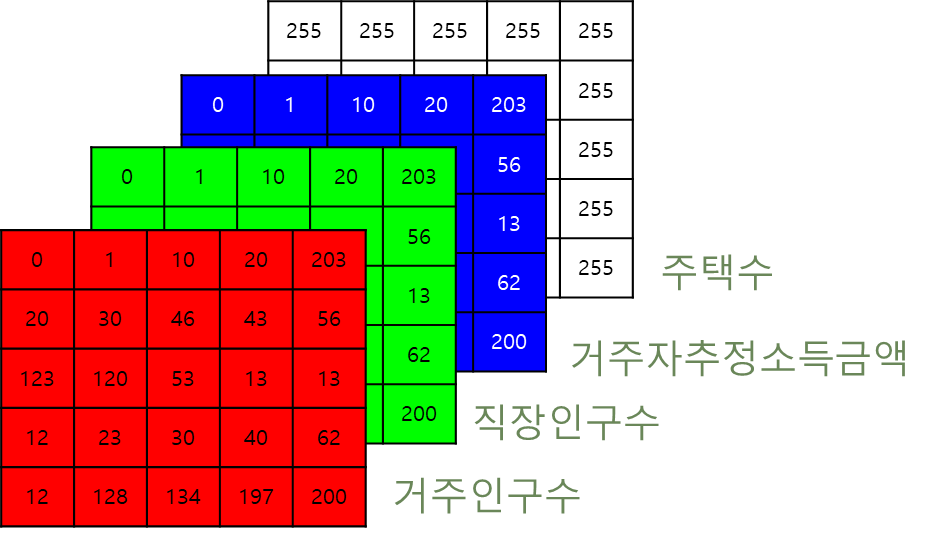

In [ ]:
# Output 위젯 생성
out = ipywidgets.Output()

def display_grid(X, first_idx, last_idx):
    """Displays a grid of values from X based on specified indices.

    Args:
      X: A 4D numpy array.
      first_idx: The index of the first dimension to select.
      last_idx: The index of the last dimension to select.
    """
    if first_idx < 0 or first_idx >= X.shape[0] or last_idx < 0 or last_idx >= X.shape[3]:
        print("Invalid indices.")
        return

    selected_data = X[first_idx, :, :, last_idx]

    with out:
        # 이전 출력 지우기
        clear_output(wait=True)

        print("매출액(월) : " + "{:,.0f}".format(Y[first_idx]) + " 천원")

        # 새 이미지 그리기
        fig, ax = plt.subplots()
        im = ax.imshow(selected_data, cmap='Reds', interpolation='nearest')

        # Add colorbar
        fig.colorbar(im, ax=ax)
        plt.show()

# Create interactive widgets
first_idx_slider = ipywidgets.IntSlider(value=0, min=0, max=X.shape[0] - 1, description='First Index')
last_idx_slider = ipywidgets.IntSlider(value=0, min=0, max=X.shape[3] - 1, description='Last Index')

# Define a function to be called when slider values change
def on_slider_change(change):
    display_grid(X, first_idx_slider.value, last_idx_slider.value)

# Observe slider changes
first_idx_slider.observe(on_slider_change, names='value')
last_idx_slider.observe(on_slider_change, names='value')

# Display widgets and output area
display(ipywidgets.VBox([first_idx_slider, last_idx_slider, out]))

# 초기화면에 그리드 출력
display_grid(X, first_idx_slider.value, last_idx_slider.value)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Y를 정규화합니다.
scaler = MinMaxScaler()
Y_normalized = scaler.fit_transform(Y.reshape(-1, 1))

# Y_normalized를 사용하여 모델을 학습시킬 준비가 되었습니다.

print("Y_normalized shape:", Y_normalized.shape)

In [ ]:
#CNN 네트워크 만들기

inputs = layers.Input(shape=(X.shape[1], X.shape[2], X.shape[3])) # Updated input shape to 3 based on X.shape
net = layers.BatchNormalization()(inputs)  # BatchNormalization 추가

net = layers.Conv2D(10, kernel_size=2, padding='same')(net)
net = layers.ReLU()(net)

net = layers.MaxPool2D(pool_size=2)(net)

net = layers.Conv2D(20, kernel_size=2, padding='same')(net)
net = layers.ReLU()(net)

net = layers.MaxPool2D(pool_size=2)(net)

net = layers.Conv2D(10, kernel_size=2, padding='same')(net)
net = layers.ReLU()(net)

net = layers.MaxPool2D(pool_size=2)(net)


net = layers.Flatten()(net)

net = layers.Dense(10, activation='relu')(net)
net = layers.Dropout(0.2)(net)

net = layers.Dense(1, activation='linear')(net)


model = Model(inputs=inputs, outputs=net)
model.compile(
    loss='mse',  #mse, mean_absolute_error
    optimizer='adam',
    metrics=['MAE']
)
model.summary()

In [ ]:
hist = model.fit(X, Y_normalized, epochs=100)

In [ ]:
# prompt: model의 예측 값을 Y_predicted_original_scale = scaler.inverse_transform(Y_predicted) 스케일 변경한 후  실제 y와 비교해줘 비교 결과를 차트로 표현해줘

Y_predicted = model.predict(X)  # 모델 예측 실행
Y_predicted_original_scale = scaler.inverse_transform(Y_predicted)  # 예측 값을 원래 스케일로 변환

# 실제 Y 값과 예측된 Y 값을 비교하는 차트를 생성합니다.
plt.figure(figsize=(10, 6))
plt.plot(Y, label='Actual Y')
plt.plot(Y_predicted_original_scale, label='Predicted Y')
plt.xlabel('Data Point')
plt.ylabel('Value')
plt.title('Actual vs Predicted Y')
plt.legend()
plt.show()

In [ ]:
#flatten layer 확인
new_model = Model(model.input,model.layers[11].output) #flatten 결과 비교
new_model.summary()

predict = new_model.predict(X)

In [ ]:
#flatten 값 클러스터링
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3).fit(predict)
result_kmean = np.array(kmeans.labels_)
result_kmean

In [ ]:
#클러스터링 별로 출력해 보기

view_cluster =0


f_cls = np.where(result_kmean == view_cluster)[0]

print("거주인구")
fig = plt.figure(figsize=(15,5))
for idx in range(len(f_cls)) :
  img = X[f_cls[idx],:,:,0]
  img = img.astype('int')
  ax = fig.add_subplot(int((len(f_cls)) / 5+1), 5, idx+1)

  ax.imshow(img, cmap='Reds', vmin=0, vmax=1500)
  # Y[idx]가 numpy 배열일 수 있으므로 스칼라 값으로 접근
  sales_value = Y[f_cls[idx]].item()
  ax.set_title("sales : " + "{:,.0f}".format(sales_value) + "원")

  ax.axis('off')
plt.show()


print("직장인구")
fig = plt.figure(figsize=(15,5))
for idx in range(len(f_cls)) :

  img = X[f_cls[idx],:,:,1]
  img = img.astype('int')

  ax = fig.add_subplot(int((len(f_cls)) / 5+1), 5, idx+1)

  ax.imshow(img, cmap='Blues', vmin=0, vmax=300)
  # Y[idx]가 numpy 배열일 수 있으므로 스칼라 값으로 접근
  sales_value = Y[f_cls[idx]].item()
  ax.set_title("sales : " + "{:,.0f}".format(sales_value) + "원")

  ax.axis('off')
plt.show()


print("추정소득")
fig = plt.figure(figsize=(15,5))
for idx in range(len(f_cls)) :

  img = X[f_cls[idx],:,:,2]
  img = img.astype('int')

  ax = fig.add_subplot(int((len(f_cls)) / 5+1), 5, idx+1)

  ax.imshow(img, cmap='Greens', vmin=0, vmax=200)
  # Y[idx]가 numpy 배열일 수 있으므로 스칼라 값으로 접근
  sales_value = Y[f_cls[idx]].item()
  ax.set_title("sales : " + "{:,.0f}".format(sales_value) + "원")

  ax.axis('off')
plt.show()

In [ ]:
!pip install shap

import shap
import numpy as np

In [ ]:


explainer = shap.DeepExplainer(model, X)
shap_values = explainer.shap_values(X)

# Reshape shap_values to 2D
shap_values_reshaped = shap_values.reshape(shap_values.shape[0], -1)
# Reshape X to 2D for consistency
X_reshaped = X.reshape(X.shape[0], -1)

# SHAP 값 시각화 (using reshaped arrays)
shap.summary_plot(shap_values_reshaped, X_reshaped)

In [ ]:
# prompt: 2차원 이미지 처럼 shap 를 표현해줘 실제 값대비 어느 격자의 정보를 더 중요하게 보는지

# ... (your existing code) ...

# SHAP 값 계산 (DeepExplainer 사용)
explainer = shap.DeepExplainer(model, X)
shap_values = explainer.shap_values(X)

# 이미지 형태로 SHAP 값 시각화 (heatmap)
def visualize_shap_image(X, shap_values, image_index):
    """
    특정 이미지에 대한 SHAP 값을 이미지 형태로 시각화합니다.

    Args:
        X: 입력 데이터 (4D numpy array).
        shap_values: SHAP 값 (4D numpy array).
        image_index: 시각화할 이미지의 인덱스.
    """
    image = X[image_index]
    shap_image = shap_values[image_index]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # 원본 이미지 표시
    axes[0].imshow(image[:, :, 0], cmap='gray')
    axes[0].set_title("Original Image")

    # SHAP 값 표시 (heatmap)
    axes[1].imshow(shap_image[:, :, 0], cmap='RdBu', vmin=-abs(shap_image).max(), vmax=abs(shap_image).max())
    axes[1].set_title("SHAP Values (Heatmap)")

    plt.show()

# 특정 이미지에 대한 SHAP 값 시각화
visualize_shap_image(X, shap_values, 0)  # 예시: 첫 번째 이미지에 대한 SHAP 값 시각화

# 여러 이미지에 대한 SHAP 값 시각화
for i in range(5):  # 예시: 첫 번째 5개 이미지에 대한 SHAP 값 시각화
    visualize_shap_image(X, shap_values, i)
